# 3D Computer Vision Project — Demo

End-to-end walkthrough of the pipeline:
1. Checkerboard corner detection
2. Camera calibration (Zhang's method) — intrinsics `K` + per-view extrinsics `(rvec, tvec)`
3. Object detection (cubes, targets, robot) in a scene image
4. Top-down 2D world view of detected objects

For a minimal end-to-end demonstration, see [demo.ipynb](./demo.ipynb).

## Step 0. Initialization

In [2]:
import os, glob, json, sys
sys.path.insert(0, "src")
from pathlib import Path
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

from checkerboard_detection import _find_checkerboard_corners
from camera_calibration_zhang import _project_points, compute_intrinsics, compute_extrinsics, _rodrigues
from camera_calibration_dlt import calibrate as calibrate_dlt, select_points, build_object_points_from_centers
from object_detection import _detect_cubes, _detect_targets, _detect_robot, _world_to_pixel

# Which calibration pipeline to run: "zhang" (two-step: intrinsic + extrinsic)
# or "dlt" (single-image manual picking, combined intrinsic + extrinsic).
CALIBRATION_METHOD = "zhang"

# Zhang two-step flow uses separate image sets for intrinsic vs extrinsic
INTRINSIC_DIR = Path(os.path.join("test-images", "intrinsic_calibration"))
SCENE_DIR = Path(os.path.join("test-images", "scene6"))
EXTRINSIC_DIR = SCENE_DIR / "calibration"
IMAGES_DIR = SCENE_DIR / "images"

# DLT flow uses a single image + pre-saved correspondences
DLT_POINTS_FILE = "test-images//dlt_points.json"
DLT_IMAGE       = "test-images/set4/calibration/image0086.png"

PATTERN_SIZE   = (8, 6)
SQUARE_SIZE_CM = 4.0

intrinsic_paths = sorted(glob.glob(os.path.join(INTRINSIC_DIR, "*.png")))
intrinsic_images = [Image.open(p) for p in intrinsic_paths]
extrinsic_path = Path(sorted(glob.glob(os.path.join(EXTRINSIC_DIR, "*.png")))[0])
extrinsic_image = Image.open(extrinsic_path)
scene_path = Path(sorted(glob.glob(os.path.join(IMAGES_DIR, "*.png")))[0])
scene_image = Image.open(scene_path)
print(f"{len(intrinsic_images)} intrinsic image(s) from {INTRINSIC_DIR}")
print(f"Extrinsic image: {extrinsic_path.name}")
print(f"Scene image:     {scene_path.name}")

13 intrinsic image(s) from test-images/intrinsic_calibration
Extrinsic image: image0086.png
Scene image:     image0087.png


## Step 1. Checkerboard detection

Detect the checkerboard interior-corner grid in each calibration image using OpenCV's SB detector, with sub-pixel refinement.

In [3]:
VISUALIZE_CORNER_DETECTION = False

for i, image in enumerate(intrinsic_images):
    gray = np.array(image.convert("L"), dtype=np.uint8)
    try:
        corners, _ = _find_checkerboard_corners(gray, PATTERN_SIZE)
        print(f"Image {i}: {len(corners)} corners detected")
    except RuntimeError:
        print(f"Image {i}: no corners detected")
        continue

    if VISUALIZE_CORNER_DETECTION:
        plt.figure()
        plt.imshow(image)
        plt.scatter(corners[:, 0], corners[:, 1], s=4, c="red", marker=".")
        plt.title(f"Image {i} — {len(corners)} corners")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

Image 0: 48 corners detected


[ERROR:0@569.948] global ocl.cpp:4679 createFromBinary OpenCL error CL_INVALID_VALUE (-30) during call: clCreateProgramWithBinary
[ERROR:1@569.948] global ocl.cpp:4679 createFromBinary OpenCL error CL_INVALID_VALUE (-30) during call: clCreateProgramWithBinary


Image 1: 48 corners detected
Image 2: 48 corners detected
Image 3: 48 corners detected
Image 4: 48 corners detected
Image 5: 48 corners detected
Image 6: 48 corners detected
Image 7: 48 corners detected
Image 8: 48 corners detected
Image 9: 48 corners detected
Image 10: 48 corners detected
Image 11: 48 corners detected
Image 12: 48 corners detected


## Step 2a. Intrinsic calibration

Recover the intrinsic matrix **K** from a set of checkerboard images with diverse board orientations. K is a property of the lens + sensor, calibrated once per camera.

In [4]:
# DLT backup uses cube-corner correspondences; cube centers + half-size
DLT_CUBE_CENTERS = np.array([
    [ 4.0,  -4.0, 2.0],
    [12.0,  -4.0, 2.0],
    [20.0, -12.0, 2.0],
    [ 4.0, -16.0, 2.0],
])
DLT_CUBE_HALF_SIZE_CM = 2.0
DLT_POINTS_3D = build_object_points_from_centers(
    DLT_CUBE_CENTERS, cube_half_size_cm=DLT_CUBE_HALF_SIZE_CM,
)

if CALIBRATION_METHOD == "zhang":
    K = compute_intrinsics(intrinsic_images)
elif CALIBRATION_METHOD == "dlt":
    # DLT combines intrinsic + extrinsic in one decomposition; we call it
    # here and reuse its (R, t) below.
    dlt_image = Image.open(DLT_IMAGE)
    if os.path.exists(DLT_POINTS_FILE):
        with open(DLT_POINTS_FILE) as f:
            saved = json.load(f)
        points_2d = np.asarray(saved["points_2d"], dtype=np.float64)
        points_3d = np.asarray(saved["points_3d"], dtype=np.float64)
        print(f"Loaded {len(points_2d)} saved DLT correspondences.")
    else:
        print(f"No saved correspondences — click the {len(DLT_POINTS_3D)} cube corners:")
        for i, (x, y, z) in enumerate(DLT_POINTS_3D):
            tag = "top" if i % 2 == 0 else "bot"
            print(f"  {i+1}. {tag}-front-left: ({x:+.1f}, {y:+.1f}, {z:+.1f}) cm")
        points_3d = DLT_POINTS_3D
        points_2d = select_points(
            np.asarray(dlt_image.convert("RGB")),
            n_points=len(points_3d), scale_factor=0.4,
        )
        os.makedirs(os.path.dirname(DLT_POINTS_FILE), exist_ok=True)
        with open(DLT_POINTS_FILE, "w") as f:
            json.dump({"points_2d": points_2d.tolist(),
                       "points_3d": points_3d.tolist()}, f, indent=2)
    calibration_dlt = calibrate_dlt(dlt_image, points_2d=points_2d, points_3d=points_3d)
    K = calibration_dlt["K"]
else:
    raise ValueError(f"Unknown CALIBRATION_METHOD: {CALIBRATION_METHOD!r}")

print(f"\n=== Intrinsics ({CALIBRATION_METHOD}) ===")
print(f"fx={K[0, 0]:.1f}, fy={K[1, 1]:.1f}")
print(f"cx={K[0, 2]:.1f}, cy={K[1, 2]:.1f}")

[compute_intrinsics] Zhang's K:
[[ 6.5e+03 -3.6e+03 -6.2e+03]
 [ 0.0e+00  3.2e+02 -3.2e+03]
 [ 0.0e+00  0.0e+00  1.0e+00]]
[compute_intrinsics] Fallback to default K estimate
[compute_intrinsics] RMS reprojection error: 3.6187 px (13 views)

=== Intrinsics (zhang) ===
fx=7927.5, fy=7927.5
cx=2710.1, cy=1036.8


## Step 2b. Extrinsic calibration

Recover the scene pose **(R, t)** — where the camera is in the world for *this* scene — by running `solvePnP` on the extrinsic calibration image. Runs once per scene.

Scene pose recovered via solvePnP (reprojection RMS: 1.056 px)


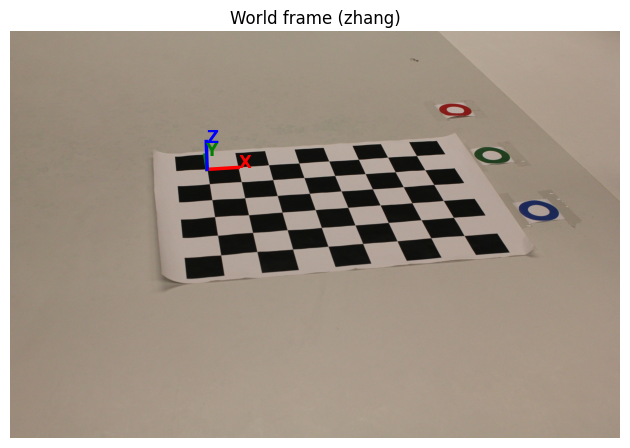

In [5]:
if CALIBRATION_METHOD == "zhang":
    R_scene, t_scene, reproj_rms = compute_extrinsics(extrinsic_image, K)
    overlay_image = extrinsic_image
    print(f"Scene pose recovered via solvePnP (reprojection RMS: {reproj_rms:.3f} px)")
else:
    # DLT already produced (R, t) alongside K
    R_scene, _ = _rodrigues(calibration_dlt["rvecs"][-1])
    t_scene = calibration_dlt["tvecs"][-1].ravel()
    overlay_image = dlt_image
    print("Scene pose taken from DLT decomposition.")

# Pack into a dict so downstream cells can treat both methods uniformly
calibration = {
    "K": K,
    "dist": np.zeros((1, 5)),
    "image_size": overlay_image.size,
    "R_scene": R_scene,
    "t_scene": t_scene,
}

# Overlay the world frame on the extrinsic calibration image
axis_length_cm = SQUARE_SIZE_CM
world_frame = np.array([[0, 0, 0],
                        [axis_length_cm,  0,              0],
                        [0,               axis_length_cm, 0],
                        [0,               0,              axis_length_cm]],
                       dtype=np.float64)

# Project via K, R, t directly (bypasses _project_points which wants rvec)
def project(pts):
    cam = (R_scene @ pts.T + t_scene[:, None])
    img_h = K @ cam
    return (img_h[:2] / img_h[2]).T

axes_image = project(world_frame)
origin_px = axes_image[0]

plt.figure()
plt.imshow(overlay_image)
for axis_index, color, label in [(1, "red", "X"), (2, "green", "Y"), (3, "blue", "Z")]:
    end_px = axes_image[axis_index]
    plt.plot([origin_px[0], end_px[0]], [origin_px[1], end_px[1]],
             color=color, linewidth=2.5)
    plt.text(end_px[0], end_px[1], label, color=color,
             fontsize=12, fontweight="bold")
plt.title(f"World frame ({CALIBRATION_METHOD})")
plt.axis("off")
plt.tight_layout()
plt.show()

## Step 3. Object detection in a scene image

In [6]:
def world_to_pixel(world_xyz):
    """Project a world-frame point to pixel coords using the current scene pose."""
    return _world_to_pixel(world_xyz, calibration["K"], R_scene, t_scene)

hsv = cv2.cvtColor(cv2.cvtColor(np.array(scene_image), cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2HSV)
cubes = _detect_cubes(hsv, calibration, R_scene, t_scene)
targets = _detect_targets(hsv, calibration, R_scene, t_scene)
try:
    robot = _detect_robot(hsv, calibration, R_scene, t_scene)
except RuntimeError as e:
    print(f"Robot detection failed: {e}")
    robot = None

print(f"Cubes:   {list(cubes)}")
print(f"Targets: {list(targets)}")
if robot is not None:
    print(f"Robot:   pos=({robot['pos'][0]:+.1f}, {robot['pos'][1]:+.1f}) cm, "
          f"heading={np.degrees(robot['heading']):+.1f} deg")

LinAlgError: 0-dimensional array given. Array must be at least two-dimensional

In [ ]:
plt.figure()
plt.imshow(scene_image)

# World-frame axes
origin_px = world_to_pixel([0.0, 0.0, 0.0])
for i, (axis_vec, color, label) in enumerate([
        ([SQUARE_SIZE_CM,  0,             0], "red",   "X"),
        ([0,               SQUARE_SIZE_CM, 0], "green", "Y"),
        ([0,               0,             SQUARE_SIZE_CM], "blue",  "Z")]):
    end_px = world_to_pixel(axis_vec)
    plt.plot([origin_px[0], end_px[0]], [origin_px[1], end_px[1]],
             color=color, linewidth=2.5, zorder=i+2)
    plt.text(end_px[0], end_px[1], label, color=color,
             fontsize=12, fontweight="bold", zorder=i+2)

# Cubes (solid) + floor shadow at z=0
for color, xyz in cubes.items():
    u, v = world_to_pixel(xyz)
    us, vs = world_to_pixel([xyz[0], xyz[1], 0.0])
    plt.scatter(u, v, s=140, c=color, marker="s", linewidths=2.0, label=f"cube:{color}")
    plt.scatter(us, vs, s=140, c=color, marker="s", alpha=0.4)

# Targets (floor)
for color, xyz in targets.items():
    u, v = world_to_pixel(xyz)
    plt.scatter(u, v, s=140, facecolors="none", edgecolors=color,
                linewidths=5.0, marker="o", label=f"target:{color}")

# Robot body + floor shadow
if robot is not None:
    uf, vf = world_to_pixel(robot["front"])
    ub, vb = world_to_pixel(robot["back"])
    ufs, vfs = world_to_pixel([robot["front"][0], robot["front"][1], 0.0])
    ubs, vbs = world_to_pixel([robot["back"][0],  robot["back"][1],  0.0])
    plt.plot([ubs, ufs], [vbs, vfs], color="yellow", linewidth=3.0, alpha=0.5, zorder=0)
    plt.plot([ub, uf], [vb, vf], color="yellow", linewidth=3, zorder=1)
    plt.scatter(uf, vf, s=120, c="yellow",  marker=".", label="robot front")
    plt.scatter(ub, vb, s=120, c="magenta", marker=".", label="robot back")
    plt.scatter(ufs, vfs, s=120, c="yellow",  marker=".", alpha=0.4)
    plt.scatter(ubs, vbs, s=120, c="magenta", marker=".", alpha=0.4)

plt.title(f"Detections on {scene_path.name}")
plt.legend(fontsize=8)
plt.axis("off")
plt.tight_layout()
plt.show()

## Step 4. Top-down world view

In [ ]:
plt.figure()

# World axes at origin
plt.plot([0, SQUARE_SIZE_CM], [0, 0], color="red",   linewidth=2.5)
plt.plot([0, 0], [0, SQUARE_SIZE_CM], color="green", linewidth=2.5)
plt.text(SQUARE_SIZE_CM, 0, "X", color="red",   fontsize=12, fontweight="bold")
plt.text(0, SQUARE_SIZE_CM, "Y", color="green", fontsize=12, fontweight="bold")

for color, xyz in cubes.items():
    plt.scatter(xyz[0], xyz[1], s=140, c=color, marker="s",
                linewidths=2.0, label=f"cube:{color}")
for color, xyz in targets.items():
    plt.scatter(xyz[0], xyz[1], s=140, facecolors="none", edgecolors=color,
                linewidths=5.0, marker="o", label=f"target:{color}")
if robot is not None:
    bx, by, _  = robot["back"]
    fx_, fy_, _ = robot["front"]
    plt.plot([bx, fx_], [by, fy_], color="yellow", linewidth=3, zorder=5)
    plt.scatter(fx_, fy_, s=120, c="yellow",  marker=".", label="robot front",  zorder=6)
    plt.scatter(bx, by,  s=120, c="magenta", marker=".", label="robot back",  zorder=5)

plt.xlabel("X (cm)")
plt.ylabel("Y (cm)")
plt.title("Top-down world view")
plt.axis("equal")
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## Step 5. Robot control — plan pick-and-place

For each cube colour, call `_plan_for_color` to get a structured list of plan steps. The planner mutates `robot_state` so consecutive calls chain naturally. `_translate` then serializes the steps to the assignment's `cmd; cmd; ...` string format.

In [ ]:
from robot_control import _plan_for_color, _translate, GRABBER_OFFSET_CM

BLOCK_ORDER = ["red", "green", "blue"]

robot_state = {"pos": robot["pos"][:2].copy(), "heading": robot["heading"]}
all_steps = []

print(f"Robot start: ({robot_state['pos'][0]:+.1f}, {robot_state['pos'][1]:+.1f}) cm, "
      f"heading: {np.degrees(robot_state['heading']):+.1f} deg")

for color in BLOCK_ORDER:
    try:
        steps = _plan_for_color(color, robot_state, cubes, targets)
    except KeyError as e:
        print(f"Skipping {color}: {e}")
        continue
    print(f"\nCommands for {color} cube:\n{_translate(steps)}")
    all_steps.extend(steps)

n_grabs = sum(1 for s in all_steps if s["cmd"] == "grab")
print(f"\nCombined command string:\n{_translate(all_steps)}")

## Step 6. Animate the robot

Simulate the robot's pose over time by densely sampling each plan step: turns sweep the heading, straight drives interpolate position, and `grab`/`let_go` toggle which cube (if any) is being carried. The first animation shows a top-down world view; the second overlays the same motion on the scene image using the calibrated pose.

In [ ]:
import matplotlib.animation as animation
import matplotlib as mpl
from IPython.display import HTML
from object_detection import ROBOT_FRONT_HEIGHT_CM

# Allow larger embedded animations (default 20 MB is too small for ~200 frames)
mpl.rcParams['animation.embed_limit'] = 64.0

# Which cube colour is moved in each pick-and-place cycle (in BLOCK_ORDER,
# skipping any colour whose cube/target wasn't detected)
moved_colors = [c for c in BLOCK_ORDER if c in cubes and c in targets]

def simulate(steps, start_pos, start_heading, cycle_colors,
             samples_per_turn_deg=2.0, samples_per_go=8):
    pos = np.asarray(start_pos, dtype=float).copy()
    heading = float(start_heading)
    cycle = 0
    held = None
    frames = [(pos.copy(), heading, held)]
    for step in steps:
        if step['cmd'] == 'turn':
            total_deg = step['param']
            n = max(2, int(abs(total_deg) / samples_per_turn_deg) + 1)
            for frac in np.linspace(0.0, 1.0, n)[1:]:
                h = heading + np.radians(total_deg) * frac
                frames.append((pos.copy(), h, held))
            heading = step['heading']
        elif step['cmd'] == 'go':
            end_pos = step['pos']
            for frac in np.linspace(0.0, 1.0, samples_per_go)[1:]:
                frames.append((pos + frac * (end_pos - pos), heading, held))
            pos = end_pos.copy()
        elif step['cmd'] == 'grab':
            held = cycle_colors[cycle] if cycle < len(cycle_colors) else None
            frames.append((pos.copy(), heading, held))
        elif step['cmd'] == 'let_go':
            held = None
            frames.append((pos.copy(), heading, held))
            cycle += 1
    return frames

start_pos = np.asarray(robot['pos'][:2], dtype=float)
start_heading = float(robot['heading'])
frames = simulate(all_steps, start_pos, start_heading, moved_colors)
print(f'Generated {len(frames)} animation frames.')

In [ ]:
fig_top, ax_top = plt.subplots(figsize=(10, 6))

for c, xyz in cubes.items():
    ax_top.scatter(xyz[0], xyz[1], s=140, c=c, marker='s', alpha=0.35,
                   edgecolors='none', label=f'cube start:{c}')
for c, xyz in targets.items():
    ax_top.scatter(xyz[0], xyz[1], s=140, facecolors='none', edgecolors=c,
                   linewidths=5.0, marker='o', label=f'target:{c}')

center_trail,  = ax_top.plot([], [], color='magenta', linestyle='--',
                             linewidth=1.2, zorder=1, label='center trail')
grabber_trail, = ax_top.plot([], [], color='yellow', linewidth=1.5,
                             zorder=2, label='grabber trail')
body_line,     = ax_top.plot([], [], color='yellow', linewidth=2.5, zorder=3)
center_dot     = ax_top.scatter([], [], s=100, c='magenta', marker='o',
                                edgecolors='none', zorder=4)
grabber_dot    = ax_top.scatter([], [], s=80, c='yellow', marker='o',
                                edgecolors='none', zorder=4)
held_dot       = ax_top.scatter([], [], s=160, marker='s',
                                edgecolors='none', zorder=5)
status_text    = ax_top.text(0.02, 0.98, '', transform=ax_top.transAxes,
                             va='top', ha='left', fontsize=10,
                             bbox=dict(facecolor='white', alpha=0.75, edgecolor='gray'))

all_points = np.vstack([np.array([p for (p, _, _) in frames]),
                        np.array([p + GRABBER_OFFSET_CM *
                                  np.array([np.cos(h), np.sin(h)])
                                  for (p, h, _) in frames])])
pad = 5.0
ax_top.set_xlim(all_points[:, 0].min() - pad, all_points[:, 0].max() + pad)
ax_top.set_ylim(all_points[:, 1].min() - pad, all_points[:, 1].max() + pad)
ax_top.set_xlabel('X (cm)')
ax_top.set_ylabel('Y (cm)')
ax_top.set_title('Robot pick-and-place animation (top-down)')
ax_top.set_aspect('equal')
ax_top.grid(True, linestyle=':', alpha=0.5)

def animate_top(i):
    past = frames[: i + 1]
    centers  = np.array([p for (p, _, _) in past])
    grabbers = np.array([p + GRABBER_OFFSET_CM * np.array([np.cos(h), np.sin(h)])
                         for (p, h, _) in past])
    pos, heading, held = frames[i]
    tip = pos + GRABBER_OFFSET_CM * np.array([np.cos(heading), np.sin(heading)])

    center_trail.set_data(centers[:, 0], centers[:, 1])
    grabber_trail.set_data(grabbers[:, 0], grabbers[:, 1])
    body_line.set_data([pos[0], tip[0]], [pos[1], tip[1]])
    center_dot.set_offsets([pos])
    grabber_dot.set_offsets([tip])
    if held is not None:
        held_dot.set_offsets([tip])
        held_dot.set_facecolor(held)
        held_dot.set_visible(True)
    else:
        held_dot.set_visible(False)
    status_text.set_text(
        f'frame {i+1}/{len(frames)}\n'
        f'pos: ({pos[0]:+.1f}, {pos[1]:+.1f}) cm\n'
        f'heading: {np.degrees(heading):+.1f} deg\n'
        f'holding: {held or "—"}')
    return (center_trail, grabber_trail, body_line, center_dot,
            grabber_dot, held_dot, status_text)

anim_top = animation.FuncAnimation(
    fig_top, animate_top, frames=len(frames),
    interval=50, blit=False, repeat=False)
plt.close(fig_top)  # Prevent duplicate static figure; show only the player
HTML(anim_top.to_jshtml())